In [1]:
from src.new_models_module.shallow.xgb import SpatioTemporalXGBModel
from src.new_models_module.base.persistencemodel import PersistenceModel

In [2]:
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

from src.utils import get_data_env

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        ='2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lags            = 1

epidata_loader_basis = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-04-17, max_date=2020-06-01, horizon_size=1, horizon_leadtime=3, sequence_length=1)

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

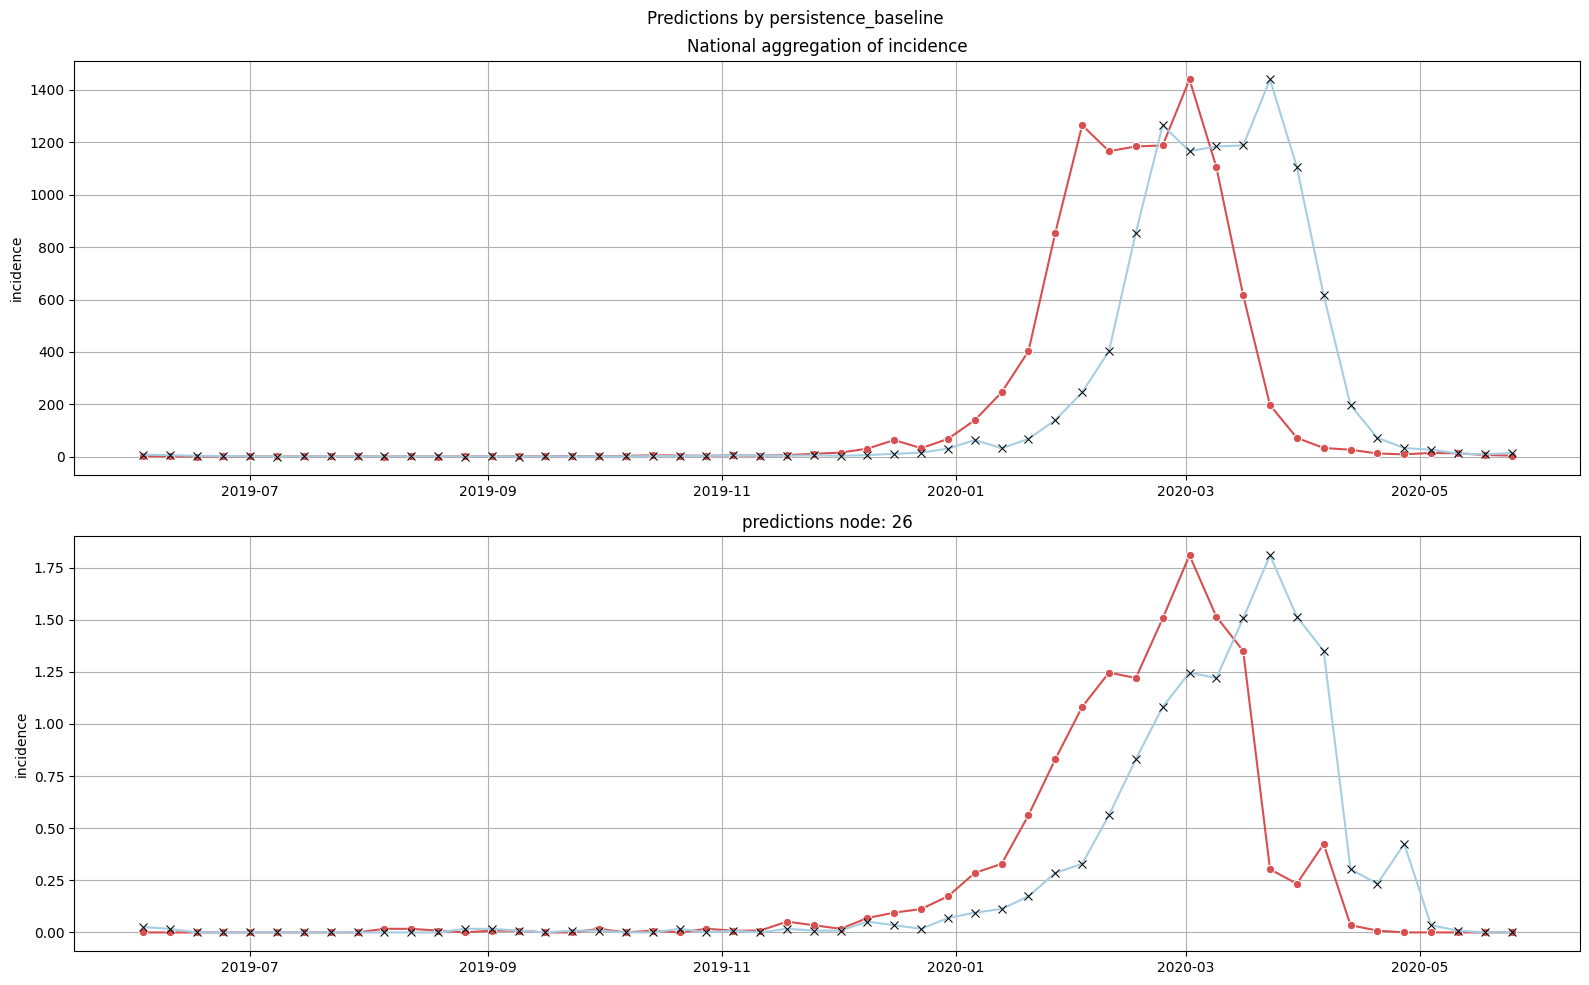

In [3]:
persistence = PersistenceModel(epidata_loader_basis, name = 'persistence_baseline')
persistence.forecast('test')
persistence.show_forecasts('test',26)

In [4]:
xgboost_loader_basis = GNNDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
xgboost_loader_basis.add_time_features()
xgboost_loader_basis.log_transform_target()
xgboost_loader_basis.set_splits(split_trainval, split_valtest)
xgboost_loader_basis.normalize()
xgboost_loader_basis.add_lagged_features(lags = lags)
xgboost_loader_basis.finalize()

xgboost_loader_idgraph= xgboost_loader_basis.copy().retrieve_graph('identity_selfmax').construct_dataloaders()
xgboost_loader_bngraph= xgboost_loader_basis.copy().retrieve_graph('boolean_neighbors_selfmean').construct_dataloaders()

xgboost_idgraph = SpatioTemporalXGBModel(xgboost_loader_idgraph, name = 'xgboost - id graph')
xgboost_idgraph.set_global_hparams(lr = 0.05, n_epochs=500)
xgboost_idgraph.set_model_hparams(max_depth = 10)
xgboost_idgraph.train(verbose = 2)
# xgboost_idgraph.forecast('train')
# xgboost_idgraph.forecast('val')
xgboost_idgraph.forecast('test')

xgboost_bngraph = SpatioTemporalXGBModel(xgboost_loader_bngraph, name = 'xgboost - bn graph')
xgboost_bngraph.set_global_hparams(lr = 0.05, n_epochs=500)
xgboost_bngraph.set_model_hparams(max_depth = 10)
xgboost_bngraph.train(verbose = 2)
# xgboost_bngraph.forecast('train')
# xgboost_bngraph.forecast('val')
xgboost_bngraph.forecast('test')

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-04-17 (+4 weeks)
berlin districts removed
⚠️ No neighbors found — skipping aggregation.
⚠️ No neighbors found — skipping aggregation.
⚠️ No neighbors found — skipping aggregation.
✓ Initialized 1 XGBoost models
[0]	validation_0-rmse:1.60769
[1]	validation_0-rmse:1.56545
[2]	validation_0-rmse:1.51816
[3]	validation_0-rmse:1.48122
[4]	validation_0-rmse:1.44723
[5]	validation_0-rmse:1.40671
[6]	validation_0-rmse:1.36925
[7]	validation_0-rmse:1.35566
[8]	validation_0-rmse:1.32760
[9]	validation_0-rmse:1.29457
[10]	validation_0-rmse:1.26397
[11]	validation_0-rmse:1.23488
[12]	validation_0-rmse:1.22427
[13]	validation_0-rmse:1.19779
[14]	validation_0-rmse:1.17807
[15]	va

<SpatioTemporalXGBModel(
    model name         : xgboost - bn graph
    model class        : SpatioTemporalXGBModel
    sequence length    : 1
    horizon size       : 1
    num neighbors      : 6.2 (avg)

    ----------- STATUS --------------
    model_initialized  : ✓
    trained            : ✗
    forecasted         : ✓
    global_hparams_set : ✓

    ----------- FORECASTS -----------
    forecasted         : ['test']

    ----------- MODEL HPARAMS -------
    max_depth          : 10
    subsample          : 0.8
    colsample_bytree   : 0.8
    reg_alpha          : 0.0
    reg_lambda         : 1.0
    tree_method        : hist
    random_state       : 42

    ----------- GLOBAL HPARAMS ------
    lr                 : 0.05
    n_epochs           : 500
    patience           : 15
    min_delta          : 0.0001

    ----------- DATA STATS ----------
    train samples      : 252000
    val samples        : 20800
    test samples       : 19200
    num features       : 6
)>

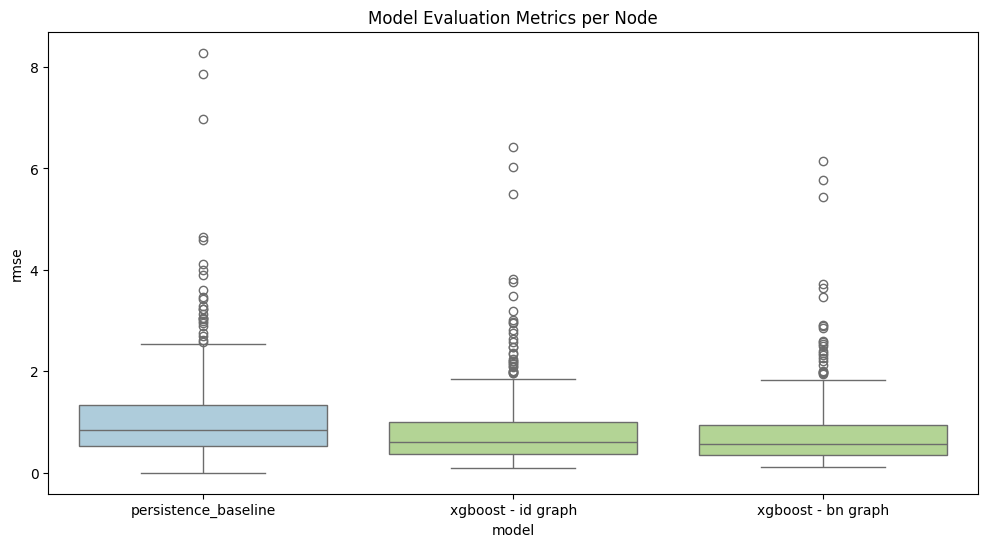

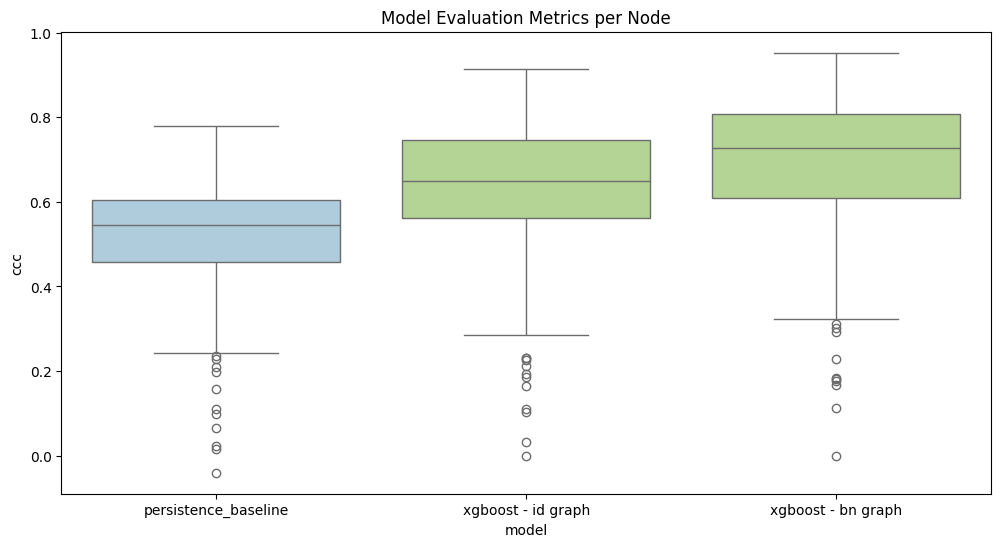

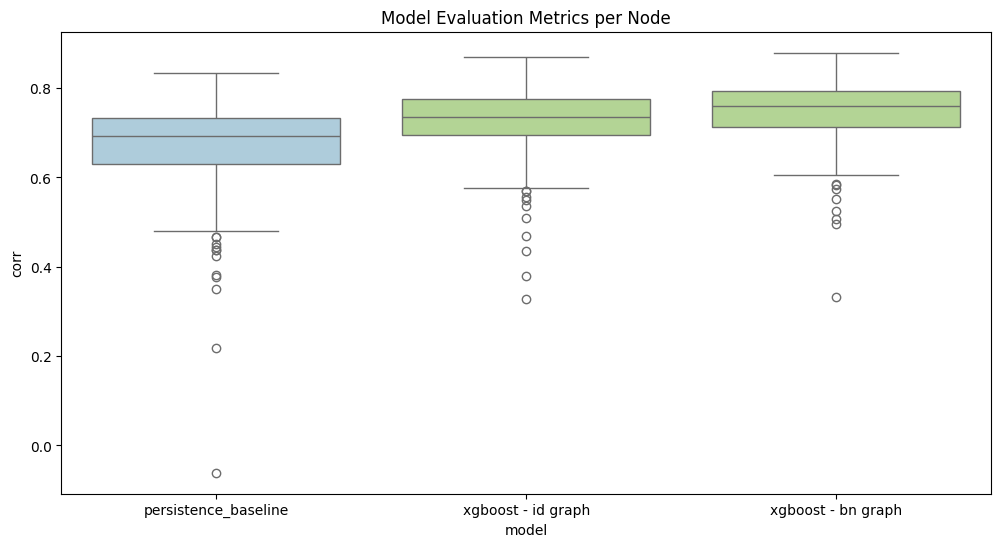

In [5]:
from src.metrics.evaluator import Evaluator

evaluation = Evaluator([persistence,xgboost_idgraph,xgboost_bngraph])
evaluation.add_evaluation()
evaluation.plot_metric('rmse', plot_type='box')
evaluation.plot_metric('ccc',  plot_type='box')
evaluation.plot_metric('corr', plot_type='box')
